In [20]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
from sklearn.model_selection import KFold
import random


In [21]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [22]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Shemo Loading for Whisper

In [23]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')

In [24]:
df = pd.read_excel('iemocap_emotions.xlsx', index_col=0)
df_cleaned = df[df['emotion'].isin(['ang', 'neu', 'hap', 'sad', 'exc'])]

In [25]:
reset_seed(42)

whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')
emo2num = {
    'hap' : 0,
    'neu' : 1,
    'sad' : 2,
    'ang' : 3,
    'exc' : 0
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger'
}

audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []


for root, folders, files in os.walk('samples'):
    for filename in files:
        file_path = os.path.join(root, filename)
        if not filename.startswith('.'):
            title = filename.replace('.wav', '')
            if title in df_cleaned['name'].tolist():
                file_path = os.path.join(root, filename)
                audio_data, sr = librosa.load(file_path, sr=16000)
                
                input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features

                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = df_cleaned[df_cleaned['name'] == title]['emotion'].item()
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [26]:
print(np.unique(np.array(labels), return_counts=True))
print(np.unique(np.array(emotions), return_counts=True))

(array([0, 1, 2, 3]), array([1636, 1708, 1084, 1103]))
(array(['ang', 'exc', 'hap', 'neu', 'sad'], dtype='<U3'), array([1103, 1041,  595, 1708, 1084]))


In [27]:
len(features)

5531

In [28]:
reset_seed(42)
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [29]:
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [30]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 5528 5529 5530]
  Test:  index=[   8   12   15 ... 5515 5524 5525]
Fold 1:
  Train: index=[   0    1    2 ... 5526 5527 5529]
  Test:  index=[  14   19   24 ... 5523 5528 5530]
Fold 2:
  Train: index=[   1    2    3 ... 5528 5529 5530]
  Test:  index=[   0    6    7 ... 5513 5520 5527]
Fold 3:
  Train: index=[   0    3    4 ... 5527 5528 5530]
  Test:  index=[   1    2   10 ... 5522 5526 5529]
Fold 4:
  Train: index=[   0    1    2 ... 5528 5529 5530]
  Test:  index=[   3    4    5 ... 5512 5519 5521]


In [31]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [32]:
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

In [33]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels)
Fold1test = AudioDataSet(testF1features, testF1labels)

Fold2train = AudioDataSet(trainF2features, trainF2labels)
Fold2test = AudioDataSet(testF2features, testF2labels)

Fold3train = AudioDataSet(trainF3features, trainF3labels)
Fold3test = AudioDataSet(testF3features, testF3labels)

Fold4train = AudioDataSet(trainF4features, trainF4labels)
Fold4test = AudioDataSet(testF4features, testF4labels)

Fold5train = AudioDataSet(trainF5features, trainF5labels)
Fold5test = AudioDataSet(testF5features, testF5labels)



# Example of using DataLoader for batching
train_loaderF1 = DataLoader(Fold1train, batch_size=4, shuffle=True)
val_loaderF1 = DataLoader(Fold1test, batch_size=4, shuffle=False)

train_loaderF2 = DataLoader(Fold2train, batch_size=4, shuffle=True)
val_loaderF2 = DataLoader(Fold2test, batch_size=4, shuffle=False)

train_loaderF3 = DataLoader(Fold3train, batch_size=4, shuffle=True)
val_loaderF3 = DataLoader(Fold3test, batch_size=4, shuffle=False)

train_loaderF4 = DataLoader(Fold4train, batch_size=4, shuffle=True)
val_loaderF4 = DataLoader(Fold4test, batch_size=4, shuffle=False)

train_loaderF5 = DataLoader(Fold5train, batch_size=4, shuffle=True)
val_loaderF5 = DataLoader(Fold5test, batch_size=4, shuffle=False)

In [34]:
loader_lists = [(train_loaderF1, val_loaderF1), (train_loaderF2, val_loaderF2), (train_loaderF3, val_loaderF3), (train_loaderF4, val_loaderF4), (train_loaderF5, val_loaderF5)]

## Train Function for Whisper

In [35]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [36]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    batch_size = inputs.size(0)
    h = model.init_hidden(batch_size).to(device)
    output = model(inputs, h)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss} | U_Accuracy: {u_acc} | W_Accuracy: {w_acc} | Precision: {precision} | Recall: {recall} | f1: {f1}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Whisper Small attention scorer

In [37]:
reset_seed(42)

class GRUModel (nn.Module):
  def __init__(self, hidden_size=256, num_layers=1, b_directional=False):
    super(GRUModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    if b_directional == True: self.d = 2
    elif b_directional == False: self.d = 1
    self.gru = torch.nn.GRU(256, hidden_size=hidden_size, num_layers=num_layers, bias=True, batch_first=True, dropout=0.0, bidirectional=b_directional, device=device)
    self.classifier = torch.nn.Linear(in_features=self.d*hidden_size, out_features=4)

  def forward(self, x, h0):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out, _ = self.gru(out, h0)
    out = self.classifier(out[:, -1, :])  # Take the output from the last time step
    return out
  
  def init_hidden(self, batch_size):
    return torch.zeros(self.d * self.num_layers, batch_size, self.hidden_size)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 236.63 seconds, Training Loss:  1.28, Validation Loss: 1.15, Validation Accuracy:  0.48


Epoch: 2 finished in 238.62 seconds, Training Loss:  1.06, Validation Loss: 0.95, Validation Accuracy:  0.61


Epoch: 3 finished in 238.72 seconds, Training Loss:  0.91, Validation Loss: 0.83, Validation Accuracy:  0.67


Epoch: 4 finished in 238.78 seconds, Training Loss:  0.82, Validation Loss: 0.80, Validation Accuracy:  0.68


...

Epoch: 6 finished in 238.91 seconds, Training Loss:  0.72, Validation Loss: 0.80, Validation Accuracy:  0.68


Epoch: 7 finished in 239.04 seconds, Training Loss:  0.71, Validation Loss: 0.73, Validation Accuracy:  0.72


Epoch: 8 finished in 238.93 seconds, Training Loss:  0.67, Validation Loss: 0.75, Validation Accuracy:  0.71


Epoch: 9 finished in 239.05 seconds, Training Loss:  0.65, Validation Loss: 0.73, Validation Accuracy:  0.72


Epoch: 10 finished in 239.00 seconds, Training Loss:  0.63, Validation Loss: 0.75, Validation Accuracy:  0.71
Each epoch took 238.65 seconds in average.


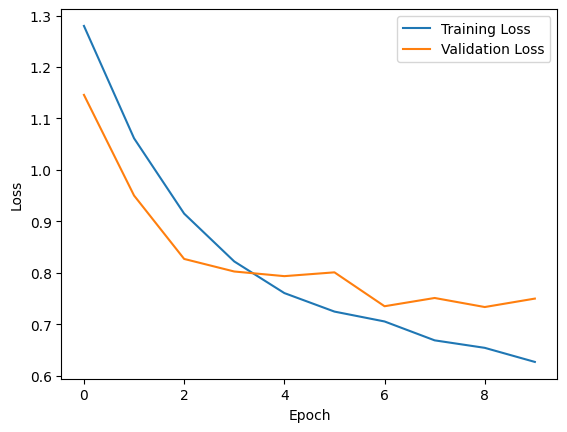

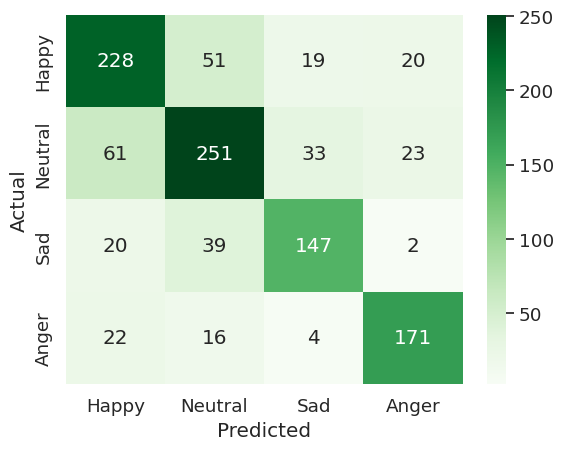

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7332442924918251 | U_Accuracy: 0.727148505026499 | W_Accuracy: 0.7199638663053297 | Precision: 0.719986359921535 | Recall: 0.7199638663053297 | f1: 0.7198137006684763
Accuracy per class:
Class 0: 0.7169811320754716
Class 1: 0.6820652173913043
Class 2: 0.7067307692307693
Class 3: 0.8028169014084507


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 239.17 seconds, Training Loss:  1.26, Validation Loss: 1.20, Validation Accuracy:  0.42


Epoch: 2 finished in 239.10 seconds, Training Loss:  1.13, Validation Loss: 1.13, Validation Accuracy:  0.46


...

Epoch: 6 finished in 238.96 seconds, Training Loss:  0.86, Validation Loss: 0.85, Validation Accuracy:  0.67


Epoch: 7 finished in 239.00 seconds, Training Loss:  0.80, Validation Loss: 0.84, Validation Accuracy:  0.67


Epoch: 8 finished in 238.86 seconds, Training Loss:  0.76, Validation Loss: 0.81, Validation Accuracy:  0.68


Epoch: 9 finished in 239.04 seconds, Training Loss:  0.74, Validation Loss: 0.84, Validation Accuracy:  0.66


Epoch: 10 finished in 239.02 seconds, Training Loss:  0.72, Validation Loss: 0.79, Validation Accuracy:  0.69
Each epoch took 239.02 seconds in average.


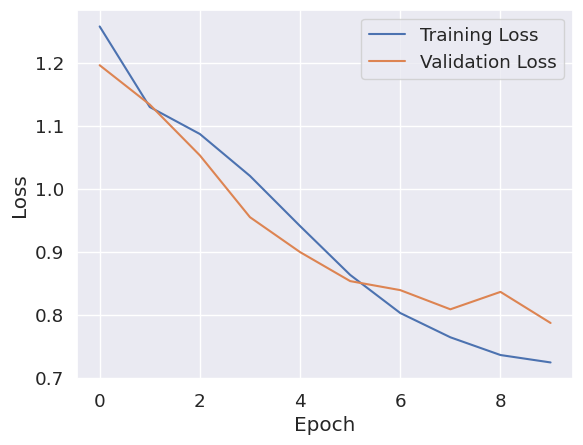

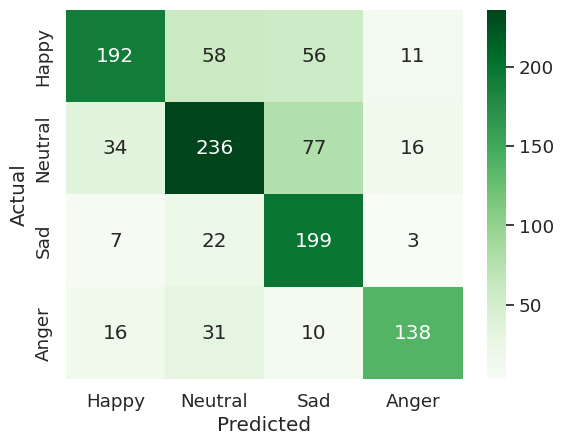

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7874560695047413 | U_Accuracy: 0.7062450359123718 | W_Accuracy: 0.6916817359855335 | Precision: 0.7105844768991758 | Recall: 0.6916817359855335 | f1: 0.6917723076477075
Accuracy per class:
Class 0: 0.6056782334384858
Class 1: 0.650137741046832
Class 2: 0.8614718614718615
Class 3: 0.7076923076923077


Epoch: 1 finished in 239.23 seconds, Training Loss:  1.23, Validation Loss: 1.05, Validation Accuracy:  0.55


Epoch: 2 finished in 239.05 seconds, Training Loss:  0.97, Validation Loss: 0.91, Validation Accuracy:  0.64


Epoch: 3 finished in 238.96 seconds, Training Loss:  0.83, Validation Loss: 0.89, Validation Accuracy:  0.65


...

Epoch: 6 finished in 239.21 seconds, Training Loss:  0.67, Validation Loss: 0.84, Validation Accuracy:  0.66


Epoch: 7 finished in 239.26 seconds, Training Loss:  0.62, Validation Loss: 0.82, Validation Accuracy:  0.68


Epoch: 8 finished in 239.45 seconds, Training Loss:  0.62, Validation Loss: 0.80, Validation Accuracy:  0.69


Epoch: 9 finished in 239.32 seconds, Training Loss:  0.59, Validation Loss: 0.79, Validation Accuracy:  0.70


Epoch: 10 finished in 239.38 seconds, Training Loss:  0.57, Validation Loss: 0.82, Validation Accuracy:  0.69
Each epoch took 239.24 seconds in average.


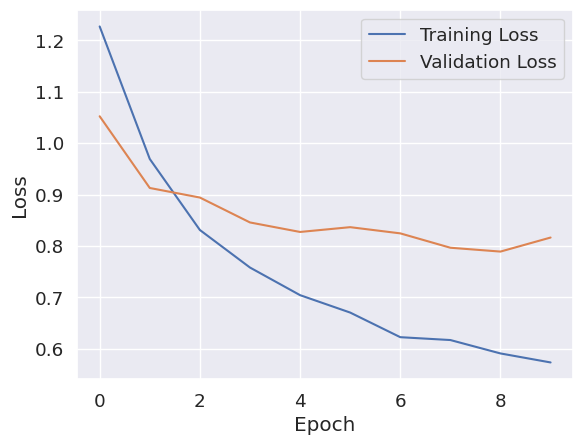

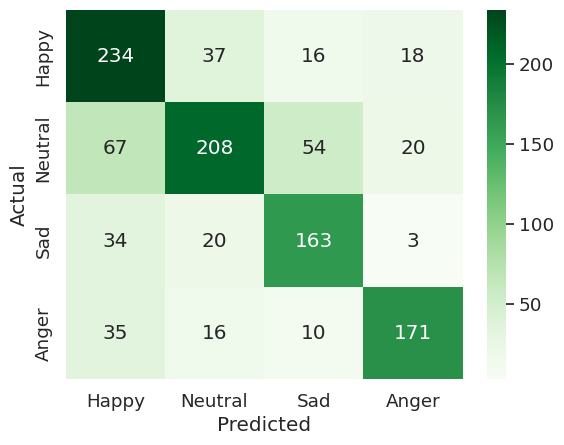

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7890199837594256 | U_Accuracy: 0.7102949274655947 | W_Accuracy: 0.701627486437613 | Precision: 0.7106062417698454 | Recall: 0.701627486437613 | f1: 0.7011961761261672
Accuracy per class:
Class 0: 0.7672131147540984
Class 1: 0.5959885386819485
Class 2: 0.740909090909091
Class 3: 0.7370689655172413


Epoch: 1 finished in 239.39 seconds, Training Loss:  1.26, Validation Loss: 1.15, Validation Accuracy:  0.45


Epoch: 2 finished in 239.30 seconds, Training Loss:  1.11, Validation Loss: 1.13, Validation Accuracy:  0.48


Epoch: 3 finished in 239.25 seconds, Training Loss:  0.99, Validation Loss: 0.94, Validation Accuracy:  0.62


...

Epoch: 6 finished in 239.33 seconds, Training Loss:  0.76, Validation Loss: 0.77, Validation Accuracy:  0.70


Epoch: 7 finished in 239.22 seconds, Training Loss:  0.72, Validation Loss: 0.77, Validation Accuracy:  0.69


Epoch: 8 finished in 239.28 seconds, Training Loss:  0.69, Validation Loss: 0.76, Validation Accuracy:  0.69


Epoch: 9 finished in 239.23 seconds, Training Loss:  0.67, Validation Loss: 0.74, Validation Accuracy:  0.70


Epoch: 10 finished in 239.28 seconds, Training Loss:  0.64, Validation Loss: 0.75, Validation Accuracy:  0.70
Each epoch took 239.30 seconds in average.


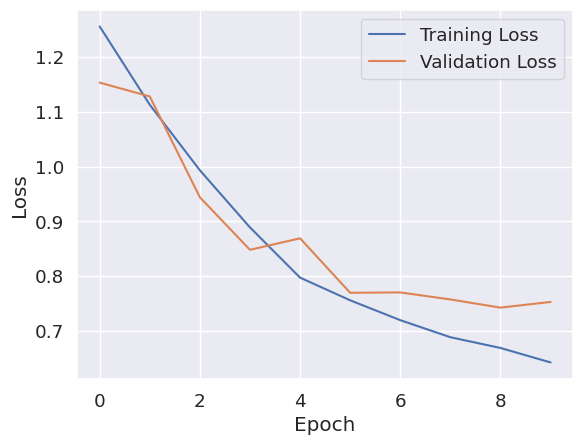

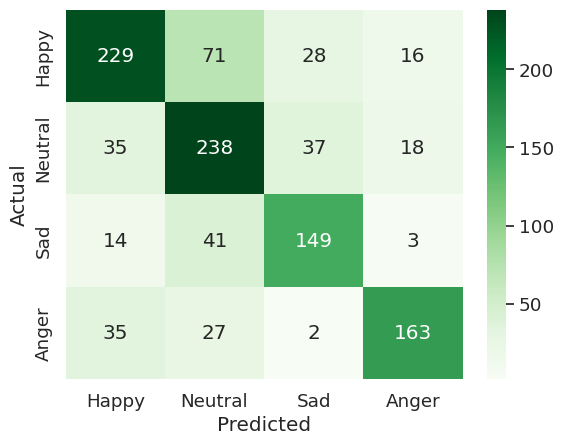

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7425295773234608 | U_Accuracy: 0.7072939669525001 | W_Accuracy: 0.7043399638336347 | Precision: 0.7111604799693696 | Recall: 0.7043399638336347 | f1: 0.7056057051261752
Accuracy per class:
Class 0: 0.6656976744186046
Class 1: 0.725609756097561
Class 2: 0.7198067632850241
Class 3: 0.7180616740088106


Epoch: 1 finished in 239.58 seconds, Training Loss:  1.23, Validation Loss: 1.34, Validation Accuracy:  0.38


Epoch: 2 finished in 239.45 seconds, Training Loss:  1.10, Validation Loss: 1.04, Validation Accuracy:  0.53


Epoch: 3 finished in 239.39 seconds, Training Loss:  0.99, Validation Loss: 0.92, Validation Accuracy:  0.59


...

Epoch: 6 finished in 239.42 seconds, Training Loss:  0.74, Validation Loss: 0.82, Validation Accuracy:  0.68


Epoch: 7 finished in 239.38 seconds, Training Loss:  0.70, Validation Loss: 0.81, Validation Accuracy:  0.69


Epoch: 8 finished in 239.34 seconds, Training Loss:  0.69, Validation Loss: 0.82, Validation Accuracy:  0.67


Epoch: 9 finished in 239.32 seconds, Training Loss:  0.66, Validation Loss: 0.78, Validation Accuracy:  0.70


Epoch: 10 finished in 239.37 seconds, Training Loss:  0.64, Validation Loss: 0.84, Validation Accuracy:  0.66
Each epoch took 239.40 seconds in average.


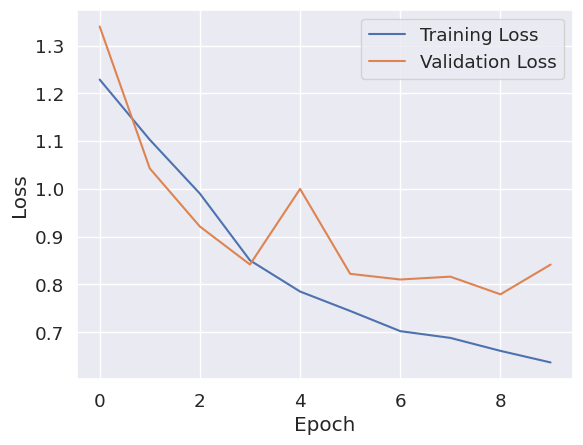

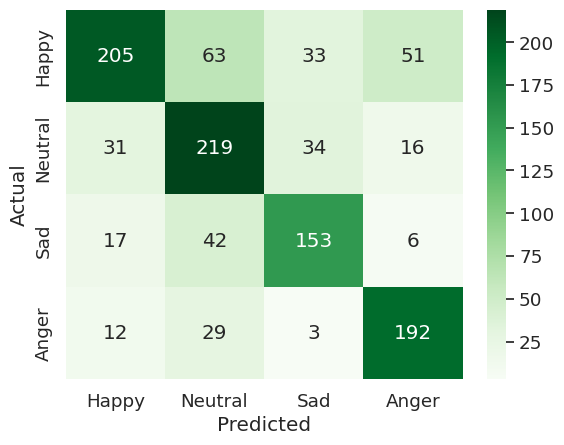

Testing finished with Loss: 0.7792416148909808 | U_Accuracy: 0.7069451370138958 | W_Accuracy: 0.6952983725135624 | Precision: 0.7043210243527711 | Recall: 0.6952983725135624 | f1: 0.6937456105609274
Accuracy per class:
Class 0: 0.5823863636363636
Class 1: 0.73
Class 2: 0.7018348623853211
Class 3: 0.8135593220338984


In [38]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = GRUModel(num_layers=2 ,b_directional=True)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.gru.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requeres_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(model, f'iemo_whisper_gru_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'iemo_whisper_gru_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)